In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

In [40]:
car_dataset = pd.read_csv('car_data_sl.csv')

In [41]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,50.25,83.85,27000,Petrol,Dealer,Manual,0
1,sx4,2013,71.25,143.10,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,108.75,147.75,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,42.75,62.25,5200,Petrol,Dealer,Manual,0
4,swift,2014,69.00,103.05,42450,Diesel,Dealer,Manual,0


In [42]:
car_dataset.shape

(301, 9)

In [43]:
car_dataset.info

<bound method DataFrame.info of     Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0       ritz  2014          50.25          83.85       27000    Petrol   
1        sx4  2013          71.25         143.10       43000    Diesel   
2       ciaz  2017         108.75         147.75        6900    Petrol   
3    wagon r  2011          42.75          62.25        5200    Petrol   
4      swift  2014          69.00         103.05       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016         142.50         174.00       33988    Diesel   
297     brio  2015          60.00          88.50       60000    Petrol   
298     city  2009          50.25         165.00       87934    Petrol   
299     city  2017         172.50         187.50        9000    Diesel   
300     brio  2016          79.50          88.50        5464    Petrol   

    Seller_Type Transmission  Owner  
0        Dealer       Manual      0  
1  

In [44]:
car_dataset.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [45]:
car_dataset.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,69.919435,114.427010,36947.205980,0.043189
std,2.891554,76.242173,129.661784,38886.883882,0.247915
min,2003.000000,1.500000,4.800000,500.000000,0.000000
25%,2012.000000,13.500000,18.000000,15000.000000,0.000000
50%,2014.000000,54.000000,96.000000,32000.000000,0.000000
75%,2016.000000,90.000000,148.500000,48767.000000,0.000000
max,2018.000000,525.000000,1389.000000,500000.000000,3.000000


In [46]:
print('\nFuel Type:')
print(car_dataset['Fuel_Type'].value_counts())
print('\nSeller Type:')
print(car_dataset['Seller_Type'].value_counts())
print('\nTransmission:')
print(car_dataset['Transmission'].value_counts())
print('\nOwner:')
print(car_dataset['Owner'].value_counts())


Fuel Type:
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

Seller Type:
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64

Transmission:
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

Owner:
Owner
0    290
1     10
3      1
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of Car Selling Prices')

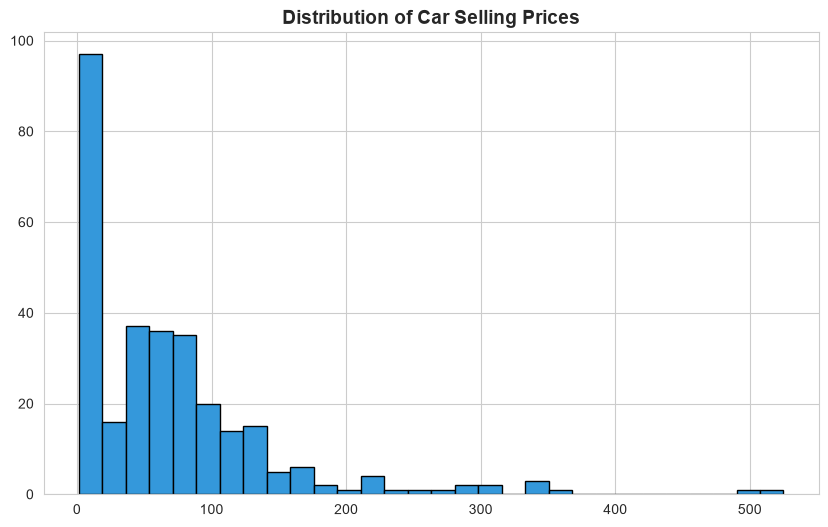

In [47]:
plt.figure(figsize=(10, 6))
plt.hist(car_dataset['Selling_Price'], bins=30, color='#3498db', edgecolor='black')
plt.title('Distribution of Car Selling Prices', fontsize=14, fontweight='bold')

Text(0.5, 1.0, 'Feature Correlation Heatmap')

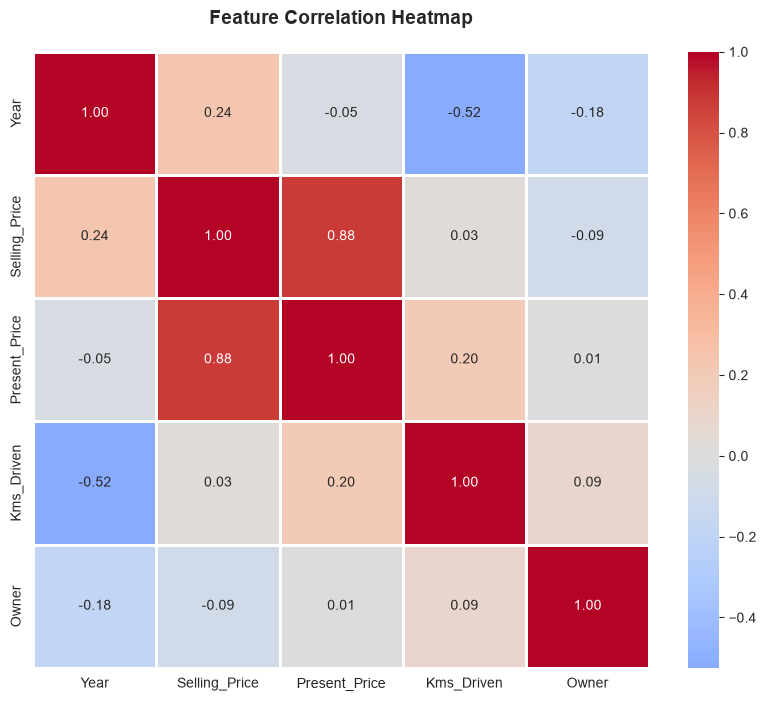

In [48]:
plt.figure(figsize=(10 , 8))
numeric_data = car_dataset.select_dtypes(include=[np.number])
correlation = numeric_data.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, square=True, linewidths=1, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)

Text(0, 0.5, 'Selling Price (Lakhs)')

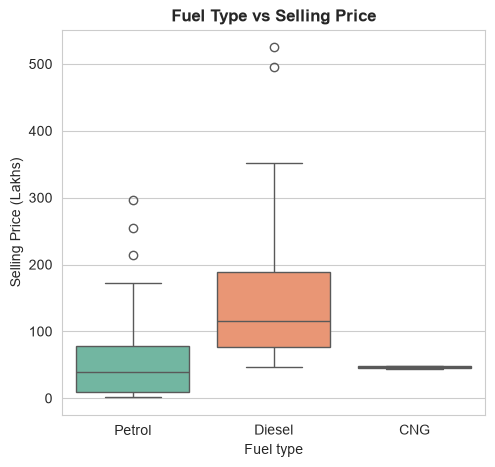

In [49]:
#Fuel type vs Selling Price
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=car_dataset, palette='Set2')
plt.title('Fuel Type vs Selling Price', fontweight='bold')
plt.xlabel('Fuel type')
plt.ylabel('Selling Price (Lakhs)')

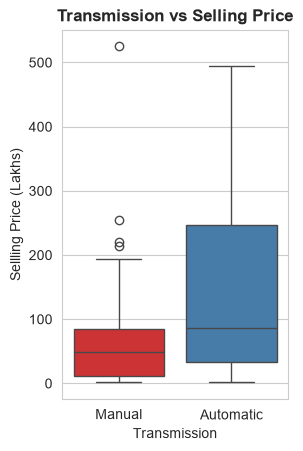

In [50]:
#Transmission vs Selling Price
plt.subplot(1,2,2)
sns.boxplot(x='Transmission', y='Selling_Price',data=car_dataset, palette='Set1')
plt.title('Transmission vs Selling Price', fontweight='bold')
plt.xlabel('Transmission')
plt.ylabel('Sellling Price (Lakhs)')
plt.show()

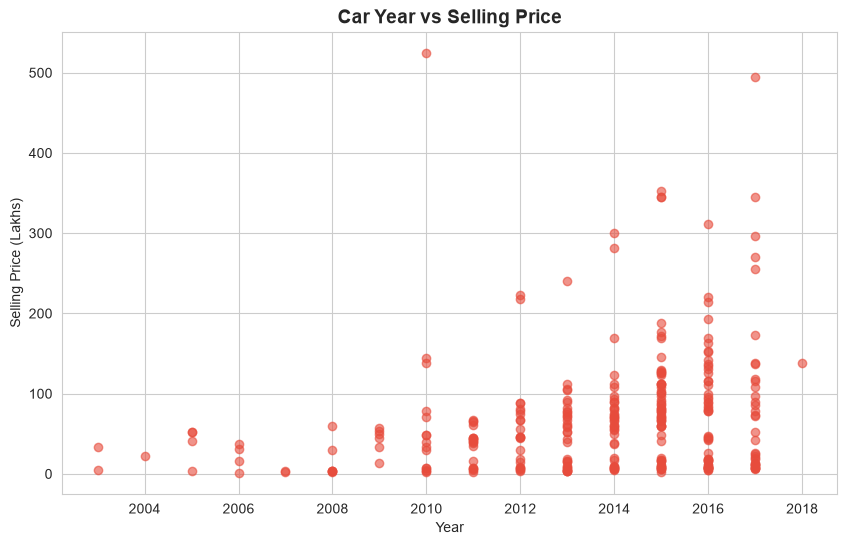

In [51]:
#Year vs Selling Price
plt.figure(figsize=(10,6))
plt.scatter(car_dataset['Year'], car_dataset['Selling_Price'], alpha=0.6, c='#e74c3c')
plt.title('Car Year vs Selling Price', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Selling Price (Lakhs)')
plt.show()

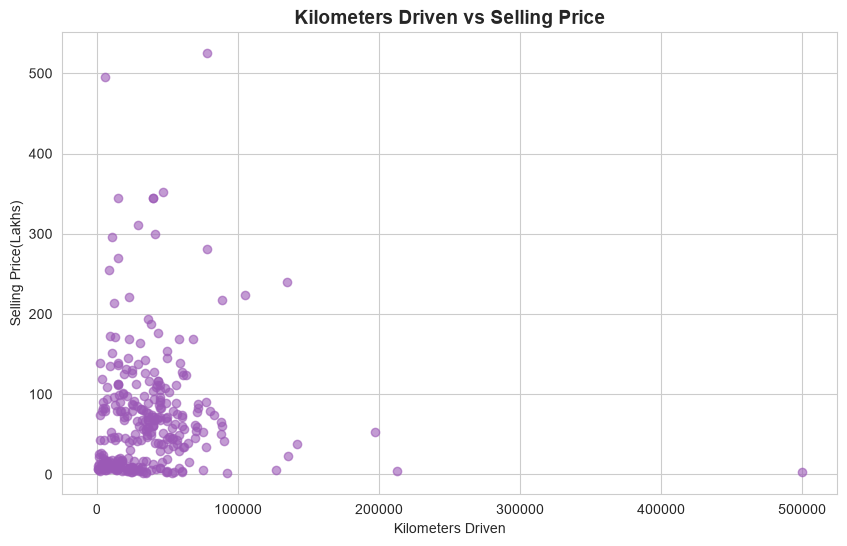

In [52]:
#Kms driven vs Selling Price

plt.figure(figsize=(10,6))
plt.scatter(car_dataset['Kms_Driven'], car_dataset['Selling_Price'], alpha=0.6, c='#9b59b6')
plt.title('Kilometers Driven vs Selling Price',fontsize=14, fontweight='bold')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price(Lakhs)')
plt.show()

In [53]:
#Encoding 

car_dataset.replace({'Fuel_Type':{'Petrol':0, 'Diesel':1, 'CNG':2}}, inplace=True)
car_dataset.replace({'Seller_Type': {'Dealer':0, 'Individual':1}}, inplace= True)
car_dataset.replace({'Transmission': {'Manual':0, 'Automatic':1}}, inplace=True)

print("Encoded Dataset")
car_dataset.head()

Encoded Dataset


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,50.25,83.85,27000,0,0,0,0
1,sx4,2013,71.25,143.10,43000,1,0,0,0
2,ciaz,2017,108.75,147.75,6900,0,0,0,0
3,wagon r,2011,42.75,62.25,5200,0,0,0,0
4,swift,2014,69.00,103.05,42450,1,0,0,0


In [54]:
x = car_dataset.drop(['Car_Name', 'Selling_Price'], axis=1)


In [55]:
x = car_dataset.drop(['Car_Name', 'Selling_Price'], axis=1)
y=car_dataset['Selling_Price']

print(x.head)

<bound method NDFrame.head of      Year  Present_Price  Kms_Driven Fuel_Type Seller_Type Transmission  Owner
0    2014          83.85       27000         0           0            0      0
1    2013         143.10       43000         1           0            0      0
2    2017         147.75        6900         0           0            0      0
3    2011          62.25        5200         0           0            0      0
4    2014         103.05       42450         1           0            0      0
..    ...            ...         ...       ...         ...          ...    ...
296  2016         174.00       33988         1           0            0      0
297  2015          88.50       60000         0           0            0      0
298  2009         165.00       87934         0           0            0      0
299  2017         187.50        9000         1           0            0      0
300  2016          88.50        5464         0           0            0      0

[301 rows x 7 columns

In [56]:
print(y.head())

0     50.25
1     71.25
2    108.75
3     42.75
4     69.00
Name: Selling_Price, dtype: float64


In [57]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)
print(f'Training Sample: {x_train.shape[0]} (80%)')

Training Sample: 240 (80%)


In [58]:
print(f'Testing Sample: {x_test.shape[0]} (20%)')

Testing Sample: 61 (20%)


In [59]:
#Model 1 Linear Regression

lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

train_pred_lr = lin_reg.predict(x_train)
train_r2_lr = metrics.r2_score(y_train, train_pred_lr)
train_mae_lr = metrics.mean_absolute_error(y_train, train_pred_lr)
train_rmse_lr = np.sqrt(metrics.mean_squared_error(y_train, train_pred_lr))

print('r2 score', train_r2_lr)
print('mae', train_mae_lr)
print('rmse', train_rmse_lr)

r2 score 0.8838169135398442
mae 17.99778171996132
rmse 26.863519691742553


In [60]:
test_pred_lr = lin_reg.predict(x_test)
test_r2_lr = metrics.r2_score(y_test, test_pred_lr)
test_mae_lr = metrics.mean_absolute_error(y_test, test_pred_lr)
test_rmse_lr = np.sqrt(metrics.mean_squared_error(y_test, test_pred_lr))

print('r2 score', test_r2_lr)
print('mae', test_mae_lr)
print('rmse',test_rmse_lr)

r2 score 0.8401523479425796
mae 19.008077085996145
rmse 25.70143855105104


Text(0.5, 1.0, 'Linear Regression - Testing')

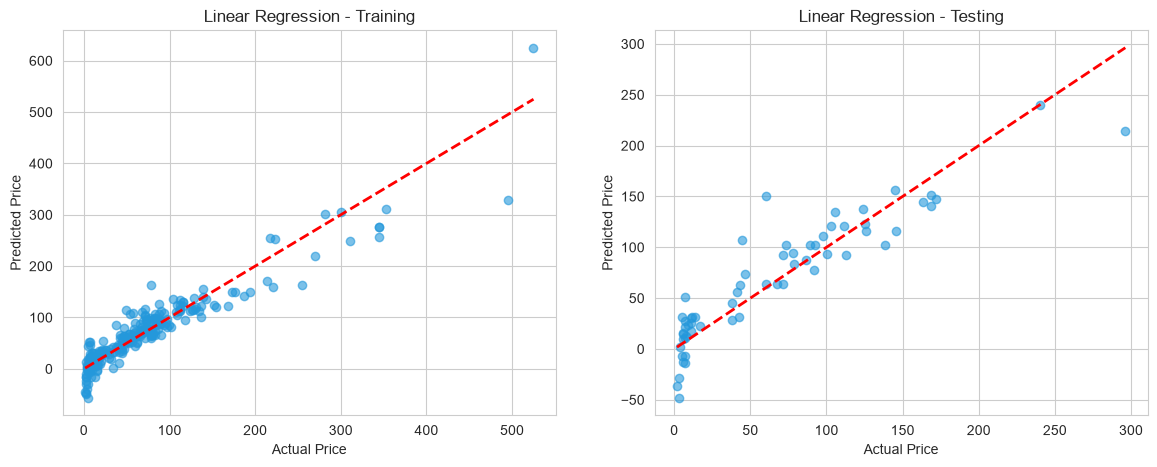

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_train, train_pred_lr, alpha=0.6, color='#2498db')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Linear Regression - Training')

axes[1].scatter(y_test, test_pred_lr, alpha=0.6, color='#2498db')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].set_title('Linear Regression - Testing')

In [62]:
#Model 2 Lasso regresion

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(x_train, y_train)

train_pred_lasso = lasso_reg.predict(x_train)
train_r2_score = metrics.r2_score(y_train, train_pred_lasso)
train_mae_lasso = metrics.mean_absolute_error(y_train, train_pred_lasso)
train_rmse_lasso = np.sqrt(metrics.mean_squared_error(y_train, train_pred_lasso))

print('r2 score', train_r2_score)
print('mae', train_mae_lasso)
print('rmse',train_rmse_lasso)

r2 score 0.8837591985151303
mae 17.91057000433994
rmse 26.870191214468015


In [63]:
test_pred_lasso = lasso_reg.predict(x_test)
test_r2_score = metrics.r2_score(y_test, test_pred_lasso)
test_mae_lasso = metrics.mean_absolute_error(y_test, test_pred_lasso)
test_rmse_lasso = np.sqrt(metrics.mean_squared_error(y_test, test_pred_lasso))

print('r2 score', test_r2_score)
print('mae', test_mae_lasso)
print('rmse',test_rmse_lasso)

r2 score 0.8421729196992589
mae 18.92596463376506
rmse 25.5384810178991


Text(0.5, 1.0, 'Lasso Regression - Testing')

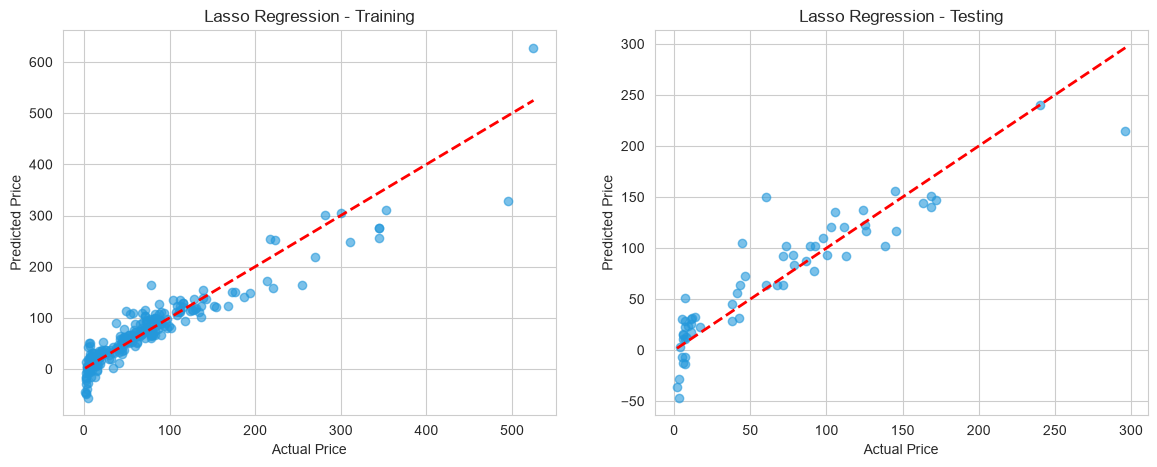

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_train, train_pred_lasso, alpha=0.6, color='#2498db')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Lasso Regression - Training')

axes[1].scatter(y_test, test_pred_lasso, alpha=0.6, color='#2498db')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].set_title('Lasso Regression - Testing')

In [65]:
#model 3 Random Forest
rf_reg = RandomForestRegressor(n_estimators=100, random_state=2)
rf_reg.fit(x_train, y_train)

train_pred_rf = rf_reg.predict(x_train)
train_r2_rf = metrics.r2_score(y_train, train_pred_rf)
train_mae_rf = metrics.mean_absolute_error(y_train, train_pred_rf)
train_rmse_rf = np.sqrt(metrics.mean_squared_error(y_train, train_pred_rf))

print('r2 score', train_r2_rf)
print('mae', train_mae_rf)
print('rmse', train_rmse_rf)

r2 score 0.9852843889331319
mae 3.7902999999999962
rmse 9.560500082043298


In [66]:
test_pred_rf = rf_reg.predict(x_test)
test_r2_rf = metrics.r2_score(y_test, test_pred_rf)
test_mae_rf = metrics.mean_absolute_error(y_test, test_pred_rf)
test_rmse_rf = np.sqrt(metrics.mean_squared_error(y_test, test_pred_rf))

print('r2 score', test_r2_rf)
print('mae', test_mae_rf)
print('rmse', test_rmse_rf)


r2 score 0.9599887963860961
mae 7.266491803278689
rmse 12.858642125173198


In [67]:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)

         Feature  Importance
1  Present_Price    0.885361
0           Year    0.082352
2     Kms_Driven    0.020069
3      Fuel_Type    0.004527
4    Seller_Type    0.003769
5   Transmission    0.003037
6          Owner    0.000884


Text(0, 0.5, 'Predicted Price')

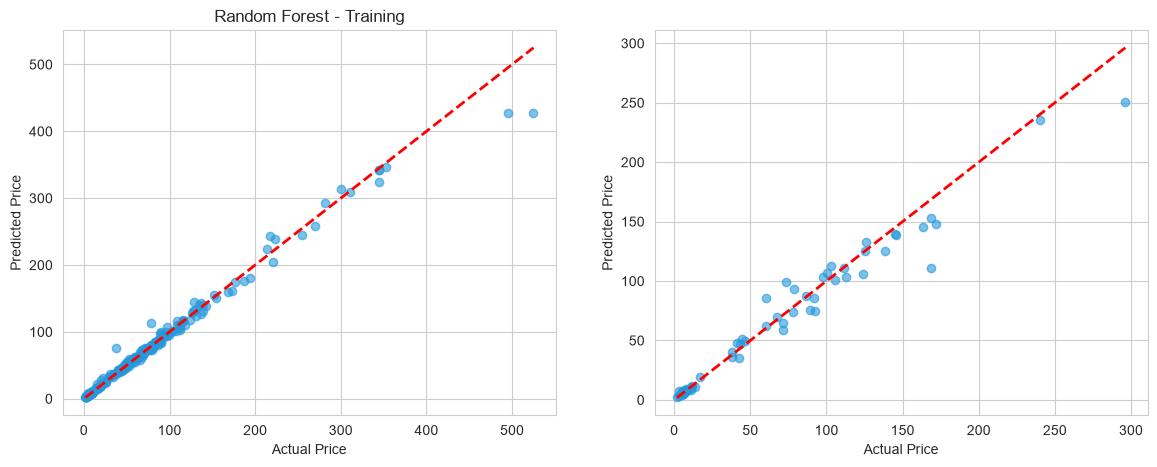

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_train, train_pred_rf, alpha=0.6, color='#2498db')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Random Forest - Training')

axes[1].scatter(y_test, test_pred_rf, alpha=0.6, color='#2498db')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')

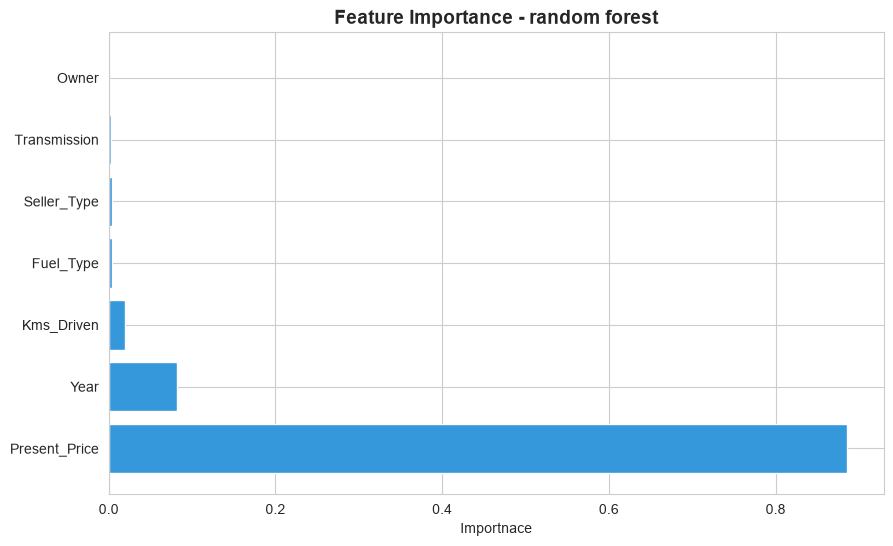

In [69]:
plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color ='#3498db')
plt.xlabel('Importnace')
plt.title('Feature Importance - random forest', fontsize=14, fontweight='bold')
plt.show()

In [70]:
#Model Comparison

print('Linear Regression', test_r2_lr)
print('Lasso Regression',test_r2_score)
print('Random Forest', test_r2_rf)

Linear Regression 0.8401523479425796
Lasso Regression 0.8421729196992589
Random Forest 0.9599887963860961


In [71]:
#Save Best Model
joblib.dump(rf_reg, 'car_prediction_model_sl.pkl')

['car_prediction_model_sl.pkl']

In [72]:
input_data = pd.DataFrame({
    'Year': [2015],
    'Present_Price': [7.0],
    'Kms_Driven': [50000],
    'Fuel_Type':[0],
    'Seller_Type':[1],
    'Transmission': [0],
    'Owner': [1]
})

prediction = rf_reg.predict(input_data)[0]
print(prediction)

4.047
